# Permutation Test H - Node metrics vs Regional TSPO in AAL

## Test H.2 - Fixed group size, random reassignment of regional TSPO data within a subject

This notebook performs test H.2 for the dataset using the AAL89 parcellation. It can be used for any other dataset, simply change the directories and variables accordingly (see attached comments).

Importing data.

In [ ]:
import numpy as np
import networkx as nx
import scipy.special as ss
from networkx import tree
import os
import glob
def adj_matrix_connected(corr_matrix,sparsity_value):
    """given the correlation matrix and the expected sparsity coefficient it can 
    happen that the corresponding thresholded matrix results in a disconnected graph
    here we force the graph to be fully connected by the computation of the minimum
    spanning tree and adding the required edges in order to have a unique connected component 
    """
    if sparsity_value == 1.0:
        adj_matrix=np.ones(corr_matrix.shape)
        np.fill_diagonal(adj_matrix,0)
        return adj_matrix
        
    
    corr_matrix =abs(corr_matrix)

    max_num_edges = ss.comb(corr_matrix.shape[0],2)
    num_edges = int(max_num_edges*sparsity_value)
    
    num_regions=corr_matrix.shape[0]
    #total number of regions in the graph
        
    totalgraph=nx.from_numpy_array(1-abs(corr_matrix))
    #extraction of a complete graph having has weight 1-abs(correlation)
    #we need to take 1-abs since the mst is taking the minimum weight graph and we want the most correlated edges to be there
    
    MST=nx.to_numpy_array(tree.minimum_spanning_tree(totalgraph).to_undirected())
    MST_adj_mat=MST
    MST_adj_mat[MST>0]==1
    MST_adj_mat=np.triu(MST_adj_mat) #put zeros in the inferior triangular matrix
    
    #put zeros in the diagonal of the corr matrix
    for i in range(num_regions):
        corr_matrix[i,i]=0
    
    values_corr=abs(np.triu(corr_matrix))
    
    cor_wo_MST=values_corr[np.triu(MST_adj_mat)==0]
    #we do not consider the correlation values which do not involve edges that are already in the MST
    
    values=list(cor_wo_MST.flatten())
    values.sort(reverse=True)
    
    #we select the maximum value of correlation to have the expected num of edges - num of edges in the mst (num regions-1)
    value_thresh=values[num_edges-(num_regions-1)-1] #-1 index start at 0
    
    adj_matrix=np.zeros(corr_matrix.shape) 
    
    #we put an edge if the value of correlation is higher than the found threshold or if the edges is required by the mst
    adj_matrix[values_corr>=value_thresh]=1
    adj_matrix[MST_adj_mat!=0]=1
    
    adj_matrix=np.triu(adj_matrix)+np.transpose(np.triu(adj_matrix)) #simmetry of the adj matrix
    
    return adj_matrix

def single_nodal_statistic(G, statistics=["d"],precision=2):
    
    """ 
    Input: a graph, a set of statistics. 

    Computes the indicated nodal statistic of a given graph for the given nodal statistic

    Output: a dictionary, for each nodal statistic we get the values for the given graph
    
    """
    nodal_stats={}
    error_case = {"0":set(G.nodes())}
    if "d" in statistics:
        
        try:
            nodal_stats["d"] = dict(G.degree())
        except:
            nodal_stats["d"] = error_case
            
    return nodal_stats

In [ ]:
controls_aal = [
    "01FO", "02LE", "03GA", "04GM", "05IM", "07NA", "08CP", "09DM", "11GL", "12LJ",
    "13AE", "14PM", "15GT", "16DT", "17LY", "19DG", "20CP", "21LJ", "22DD", "23BA"
]

anoxic_aal = [ # Effective Anoxic patients 
    "01JF", "02PD", "06BM", "07TA", "14RC"
]
traumatic_aal = [ # Effective Traumatic patients  - Patient 08PE must be excluded from studies using AICHA 
    "03DB", "08PE", "11FC", "13TL", "16FF", "22BT", "23GC", "24ZX", "26AC"
]

matrices_path =  "/Data/Correlation_Matrices/AAL" # Simply change the last path to import other atlases, e.g. AICHA
control_path = os.path.join(matrices_path, "Controls")
anoxic_path = os.path.join(matrices_path, "Anoxic")
traumatic_path = os.path.join(matrices_path, "Traumatic")

# Final filter before importing - matching IDs from lists to files to exclude non-effective subjects

control_subjects = sorted(
    s for s in glob.glob(os.path.join(control_path, "*"))
    if os.path.basename(s).split(".")[0] in controls_aal
)

anoxic_subjects = sorted(
    s for s in glob.glob(os.path.join(anoxic_path, "*"))
    if os.path.basename(s).split(".")[0] in anoxic_aal
)

traumatic_subjects = sorted(
    s for s in glob.glob(os.path.join(traumatic_path, "*"))
    if os.path.basename(s).split(".")[0] in traumatic_aal
)

# Importing correlations - Keys are IDs, values are matrices

control_correlations = {}
for sub in control_subjects:
    control_correlations[os.path.splitext(os.path.basename(sub))[0]] = np.loadtxt(sub)


traumatic_correlations = {}
for sub in traumatic_subjects:
    traumatic_correlations[os.path.splitext(os.path.basename(sub))[0]] = np.loadtxt(sub)

anoxic_correlations = {}
for sub in anoxic_subjects:
    anoxic_correlations[os.path.splitext(os.path.basename(sub))[0]] = np.loadtxt(sub)

print(f"Controls: {len(control_correlations.keys())}, Anoxic: {len(anoxic_correlations.keys())}, Traumatic: {len(traumatic_correlations.keys())}")

#  fMRI graphs
costs = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5] # AKA Graph density.
controls_fmri_graphs = {cost:{sub: None for sub in control_correlations.keys()} for cost in costs}
for cost in costs:
    for sub in control_correlations.keys(): # Keys are IDs, values are nx.Graph objects
        controls_fmri_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(control_correlations[sub], cost))

anoxic_fmri_graphs = {cost:{sub: None for sub in anoxic_correlations.keys()} for cost in costs}
for cost in costs:
    for sub in anoxic_correlations.keys():
        anoxic_fmri_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(anoxic_correlations[sub], cost))

traumatic_fmri_graphs = {cost:{sub: None for sub in traumatic_correlations.keys()} for cost in costs}
for cost in costs:
    for sub in traumatic_correlations.keys():
        traumatic_fmri_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(traumatic_correlations[sub], cost))

# We can merge the coma dataset in one dictionary

coma_fmri_graphs = {cost: {} for cost in costs}

for cost in costs:
    coma_fmri_graphs[cost] = {**anoxic_fmri_graphs[cost], **traumatic_fmri_graphs[cost]}


Controls: 20, Anoxic: 5, Traumatic: 9


Regional TSPO

In [ ]:
import pandas as pd
tspo_path = "/Data/Regional_TSPO/AAL" # Idem, change the last path element to import another atlas
control_tspo_data = {}

control_tspo_files = glob.glob(os.path.join(tspo_path, "Controls", "*"))
for file in control_tspo_files:
    id = os.path.splitext(os.path.basename(file))[0] 
    control_tspo_data[id] = pd.read_csv(file)

anoxic_tspo_data = {}

anoxic_tspo_files = glob.glob(os.path.join(tspo_path, "Anoxic", "*"))
for file in anoxic_tspo_files:
    id = os.path.splitext(os.path.basename(file))[0] 
    if id in anoxic_aal:
        anoxic_tspo_data[id] = pd.read_csv(file)

traumatic_tspo_data = {}

traumatic_tspo_files = glob.glob(os.path.join(tspo_path, "Traumatic", "*"))
for file in traumatic_tspo_files:
    id = os.path.splitext(os.path.basename(file))[0]
    if id in traumatic_aal:
        traumatic_tspo_data[id] = pd.read_csv(file)

coma_tspo_data = {**anoxic_tspo_data, **traumatic_tspo_data}

Mean of regional TSPO

Number of elements in `mode_controls` and other arrays depends on the number of nodes per atlas:
* AAL - 89
* Schaefer119 - 119
* Schaefer223 - 223
* AICHA - 391

In [ ]:
import numpy as np 

mode_controls = np.zeros((len(control_tspo_data.keys()), 89))
for i, px in enumerate(control_tspo_data.keys()):
    mode_controls[i] = control_tspo_data[px]['Mode'] # Mode is interpreted as regional TSPO
m_mode_control = np.mean(mode_controls, axis=0)

mode_anoxic = np.zeros((len(anoxic_tspo_data.keys()), 89))
for i, px in enumerate(anoxic_tspo_data.keys()):
    mode_anoxic[i] = anoxic_tspo_data[px]['Mode']

m_mode_anoxic = np.mean(mode_anoxic, axis=0)

mode_traumatic = np.zeros((len(traumatic_tspo_data.keys()), 89))
for i, px in enumerate(traumatic_tspo_data.keys()):
    mode_traumatic[i] = traumatic_tspo_data[px]['Mode']

m_mode_traumatic = np.mean(mode_traumatic, axis=0)

# Preallocate array for combined TSPO Mode data
mode_coma = np.zeros((len(anoxic_aal) + len(traumatic_aal), 89))

# Fill in TSPO Mode data for anoxic subjects
for i, px in enumerate(anoxic_aal):
    mode_coma[i] = anoxic_tspo_data[px]['Mode']

# Fill in TSPO Mode data for traumatic subjects
for i, px in enumerate(traumatic_aal):
    mode_coma[len(anoxic_subjects) + i] = traumatic_tspo_data[px]['Mode']

# Compute mean across all subjects
m_mode_coma = np.mean(mode_coma, axis=0)


Mean node metrics at group level

In [ ]:
metrics_list = ['d']
nodal_metrics_controls = {
    cost: {px: {} for px in controls_fmri_graphs[0.1].keys()} for cost in costs
}
for cost in costs:
    for px in controls_fmri_graphs[0.1].keys():
        graph = controls_fmri_graphs[cost][px]
        nodal_metrics_controls[cost][px] = single_nodal_statistic(graph, metrics_list)

mean_metrics_control = {
    cost: {metric: None for metric in metrics_list} for cost in costs
}

for cost in costs:
    for metric in metrics_list:
        mat =  np.zeros((len(controls_fmri_graphs[0.1].keys()), 89))
        for i, px in enumerate(controls_fmri_graphs[0.1].keys()):
            mat[i] = list(nodal_metrics_controls[cost][px][metric].values())
        mean_metrics_control[cost][metric] = np.mean(mat, axis=0)



nodal_metrics_anoxic = {
    cost: {px: {} for px in anoxic_fmri_graphs[0.1].keys()} for cost in costs
}
for cost in costs:
    for px in anoxic_fmri_graphs[0.1].keys():
        graph = anoxic_fmri_graphs[cost][px]
        nodal_metrics_anoxic[cost][px] = single_nodal_statistic(graph, metrics_list)

mean_metrics_anoxic = {
    cost: {metric: None for metric in metrics_list} for cost in costs
}

for cost in costs:
    for metric in metrics_list:
        mat =  np.zeros((len(anoxic_fmri_graphs[0.1].keys()), 89))
        for i, px in enumerate(anoxic_fmri_graphs[0.1].keys()):
            mat[i] = list(nodal_metrics_anoxic[cost][px][metric].values())
        mean_metrics_anoxic[cost][metric] = np.mean(mat, axis=0)



nodal_metrics_traumatic = {
    cost: {px: {} for px in traumatic_fmri_graphs[0.1].keys()} for cost in costs
}
for cost in costs:
    for px in traumatic_fmri_graphs[0.1].keys():
        graph = traumatic_fmri_graphs[cost][px]
        nodal_metrics_traumatic[cost][px] = single_nodal_statistic(graph, metrics_list)

mean_metrics_traumatic = {
    cost: {metric: None for metric in metrics_list} for cost in costs
}

for cost in costs:
    for metric in metrics_list:
        mat =  np.zeros((len(traumatic_fmri_graphs[0.1].keys()), 89))
        for i, px in enumerate(traumatic_fmri_graphs[0.1].keys()):
            mat[i] = list(nodal_metrics_traumatic[cost][px][metric].values())
        mean_metrics_traumatic[cost][metric] = np.mean(mat, axis=0)

mean_metrics_coma = {
    cost: {metric: None for metric in metrics_list} for cost in costs
}

for cost in costs:
    for metric in metrics_list:
        # Create matrices for both groups
        mat_anoxic = np.zeros((len(anoxic_correlations), 89))
        for i, px in enumerate(anoxic_correlations):
            mat_anoxic[i] = list(nodal_metrics_anoxic[cost][px][metric].values())

        mat_traumatic = np.zeros((len(traumatic_correlations), 89))
        for i, px in enumerate(traumatic_correlations):
            mat_traumatic[i] = list(nodal_metrics_traumatic[cost][px][metric].values())

        # Combine and compute mean
        coma_mat = np.vstack((mat_anoxic, mat_traumatic))
        mean_metrics_coma[cost][metric] = np.mean(coma_mat, axis=0)

mean_node_metrics_fmri = {
    "Controls": mean_metrics_control,
    "Coma": mean_metrics_coma
}

mean_tspo_metrics = {
    "Controls": m_mode_control,
    "Coma": m_mode_coma
}

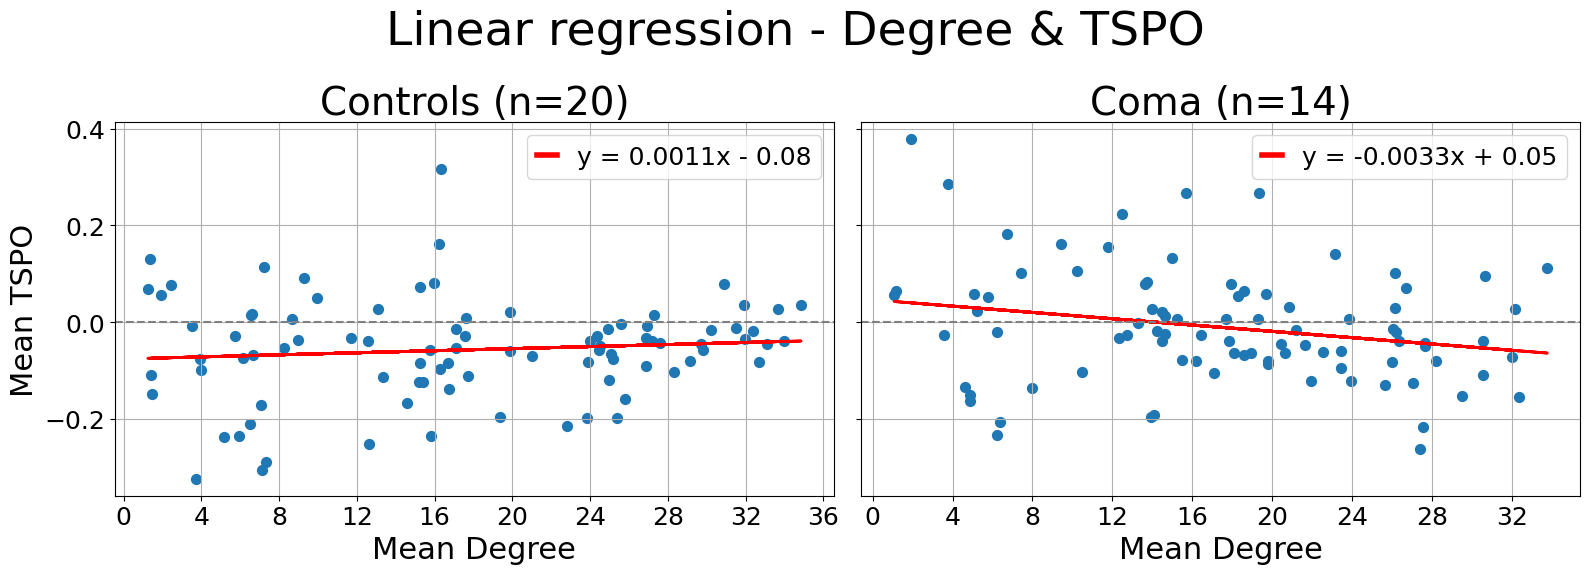

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.patheffects as path_effects 
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
# Constants
cost_level = 0.1
metric = "d" 
groups = ['Controls', 'Coma']

# Subplots: 1 row, 3 columns
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), sharey=True)

# Selected nodes (adjusted by -2) # To add labels to selected nodes

# selected_nodes = [72, 30, 35, 63]
# selected_nodes = [n - 2 for n in selected_nodes]

# # Load region names
# region_names_df = pd.read_excel("/AAL/List_regions.xlsx")
# region_names = region_names_df.iloc[:, 0].tolist()

group_sizes = {"Controls": 20, 'Coma': 14}

# Loop through groups (columns)
for group_idx, group in enumerate(groups):
    ax = axes[group_idx]

    ax.xaxis.set_major_locator(MaxNLocator(integer=True, prune='both'))
    # Inputs
    x = mean_node_metrics_fmri[group][cost_level][metric].reshape(-1, 1)
    y = mean_tspo_metrics[group]

    # Linear regression
    model = LinearRegression()
    model.fit(x, y)
    y_pred = model.predict(x)

    # Scatter plot
    ax.scatter(x, y, s=50)

    # Annotate selected nodes
    # for i in selected_nodes:
    #     ax.scatter(x[i], y[i], color='tab:orange', edgecolor='white', zorder=5, s=80)
    #     text = ax.annotate(region_names[i], (x[i][0], y[i]),
    #                        textcoords="offset points", xytext=(5, 5),
    #                        ha='left', fontsize=12, color='black')
    #     text.set_path_effects([
    #         path_effects.Stroke(linewidth=3, foreground='white'),
    #         path_effects.Normal()
    #     ])

    # for i in selected_nodes:
    #     # Default label settings
    #     offset = (5, 5)
    #     align = 'left'

    #     # Special case: Traumatic group and node 63
    #     if group == 'Traumatic' and region_names[i] == "Precuneus_R":
    #         offset = (5, 5)
    #         align = 'right'

    #     if group == 'Anoxic' and region_names[i] == "CingAnt_L":
    #         offset = (10, 10)
    #         align = 'right'


    #     if group == 'Anoxic' and region_names[i] == "Thalamus_L":
    #         offset = (0, -25)
    #         align = 'left'

    #     if group == 'Traumatic' and region_names[i] == "CingPost_R":
    #         offset = (0, -20)
    #         align = 'left'

    #     if group == 'Traumatic' and region_names[i] == "Precuneus_R":
    #         offset = (5, 10)
    #         align = 'right'


    #     ax.scatter(x[i], y[i], color='tab:orange', edgecolor='white', zorder=5, s=150)

    #     text = ax.annotate(
    #         region_names[i],
    #         (x[i][0], y[i]),
    #         textcoords="offset points",
    #         xytext=offset,
    #         ha=align,
    #         fontsize=15,
    #         color='black'
    #     )
    #     text.set_path_effects([
    #         path_effects.Stroke(linewidth=3, foreground='white'),
    #         path_effects.Normal()
    #     ])



    # Regression line
    coef = model.coef_[0]
    intercept = model.intercept_
    sign = '+' if intercept >= 0 else '-'
    label = f"y = {coef:.4f}x {sign} {abs(intercept):.2f}"
    reg_line, = ax.plot(x, y_pred, color='red', linewidth=2, label=label)

    # Custom legend handle (saalrter, thicker red line)
    custom_line = Line2D([0], [0], color='red', lw=4)  # lw=4 for thicker line
    ax.legend([custom_line], [label], fontsize=18,  handlelength=0.8)

    # Titles and labels
    ax.set_title(f"{group} (n={group_sizes[group]})", fontsize=28)
    if group_idx == 0:
        ax.set_ylabel("Mean TSPO", fontsize=22)
    ax.set_xlabel("Mean Degree", fontsize=22)

    ax.axhline(0, color='gray', linestyle='--')
    ax.grid(True)
    ax.tick_params(labelsize=18)
    #ax.legend(fontsize=18)
    
# Finalize plot
plt.suptitle("Linear regression - Degree & TSPO", fontsize=34)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


# Permutation tests - Random reassignment of subject-wise regional TSPO data

_“Is the observed slope different than expected if TSPO regional identity is meaningless?”_

In [13]:
all_mapped_ids = controls_aal + anoxic_aal + traumatic_aal
len(all_mapped_ids)

34

In [ ]:
coma_aal = anoxic_aal + traumatic_aal

In [ ]:

from sklearn.linear_model import LinearRegression

n_iterations = 10000

xcosts = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

xcoeffs = { # list of "x-coefficients" - artificial groups of xcontrols (etc.) where group membership is random, number of elements per group is fixed
    "Controls": {cost: {metric: [] for metric in metrics_list} for cost in xcosts}, 
    "Coma": {cost: {metric: [] for metric in metrics_list} for cost in xcosts},
}


num_xcontrols = 20
num_xcoma = 14 # 13 for AICHA
n_nodes = 89 # Varies depending on atlas used 



# Mean metrics control (fMRI) is already defined and won't be re-shuffled
# Same for Coma
# There's no need for "stacking"
# all this data is in the dictionary mean_node_metrics_fmri

# We keep TSPO subject data "separate" 
control_regional_tspo = {
    sub: control_tspo_data[sub]["Mode"].to_numpy()
    for sub in controls_aal
}

coma_regional_tspo = {
    sub: coma_tspo_data[sub]["Mode"].to_numpy()
    for sub in coma_aal
}

# And we shuffle it at the node level at each iteration

for it in range(n_iterations):

    xcontrol_regional_tspo = {
        sub: np.random.permutation(control_regional_tspo[sub])
        for sub in controls_aal
    }

    xcoma_regional_tspo = {
        sub: np.random.permutation(coma_regional_tspo[sub])
        for sub in coma_aal
    }

    # Now we compute group-wise means after shuffling regional tspo data

    xmode_controls = np.zeros((len(controls_aal), n_nodes))

    for si, sub in enumerate(controls_aal):
        xmode_controls[si] = xcontrol_regional_tspo[sub]

    xm_mode_control = xmode_controls.mean(axis=0)

    xmode_coma = np.zeros((len(coma_aal), n_nodes))

    for si, sub in enumerate(coma_aal):
        xmode_coma[si] = xcoma_regional_tspo[sub]

    xm_mode_coma = xmode_coma.mean(axis=0)

    xmean_tspo_metrics = {
        "Controls": xm_mode_control,
        "Coma": xm_mode_coma
    }

    # And recompute the regression coefficient

    for group in mean_node_metrics_fmri.keys():
        for cost in xcosts:
            for metric in metrics_list:
                x = mean_node_metrics_fmri[group][cost][metric].reshape(-1, 1)
                y = xmean_tspo_metrics[group]

                model = LinearRegression()
                model.fit(x,y)

                xcoeffs[group][cost][metric].append(model.coef_[0])

In [ ]:
real_slopes = {group: { # Stacks observed results to compare them with permutation results
    cost: {
        metric: None for metric in metrics_list
    } for cost in xcosts
} for group in groups}

for group in groups:
    for cost in xcosts:
        for metric in metrics_list:
            x = mean_node_metrics_fmri[group][cost][metric].reshape(-1, 1)
            y = mean_tspo_metrics[group]

            # Linear regression
            model = LinearRegression()
            model.fit(x, y)
            real_slopes[group][cost][metric] = model.coef_[0]

In [16]:
def cohens_d(original_value, bootstrap_distribution):
    mean_boot = np.mean(bootstrap_distribution)
    std_boot = np.std(bootstrap_distribution, ddof=1)  # Sample std dev
    return (original_value - mean_boot) / std_boot

In [ ]:
# RESULTS 10K
from statsmodels.stats.multitest import fdrcorrection

# define once, outside the loops
metric = 'd' 
groups = ['Controls', 'Coma']
xcost = 0.1 
p_values_uncorrected = [] # to store them

for group in groups:

    # get the bootstrap slopes and the real slope
    boot_slopes = xcoeffs[group][xcost][metric]
    real_slope  = real_slopes[group][xcost][metric]

    # Percentile of the original slope in the bootstrapped distribution
    percentile = np.mean(boot_slopes < real_slope) * 100

    # One-tailed and two-tailed p-values
    p_value_one_tailed = 1 - (percentile / 100)
    p_value_two_tailed = 2 * min(p_value_one_tailed, 1 - p_value_one_tailed)
    p_values_uncorrected.append(p_value_two_tailed) # we store each time


    # Cohen's D
    cohens_d_value = cohens_d(real_slope, boot_slopes)

    # Confidence intervals
    ci_low = np.percentile(boot_slopes, 2.5)
    ci_high = np.percentile(boot_slopes, 97.5)

    # Apply FDR correction (Benjamini-Hochberg)
    rejected, p_values_fdr = fdrcorrection(p_values_uncorrected, alpha=0.05)

# Print results
for group, raw_p, fdr_p, reject in zip(groups, p_values_uncorrected, p_values_fdr, rejected):
    print(group)
    print(f"Observed slope: {real_slope}")
    print(f"Effect size: {cohens_d_value}")
    print(f"CI: {ci_low}, {ci_high}")
    print(f"raw p = {raw_p}, FDR-corrected p = {fdr_p}, significant: {reject} \n")



Controls
Observed slope: -0.004870998910081459
Effect size: -2.5819963497069165
CI: -0.00366330751425803, 0.003815279428001921
raw p = 0.15460000000000007, FDR-corrected p = 0.15460000000000007, significant: False 

Coma
Observed slope: -0.004870998910081459
Effect size: -2.5819963497069165
CI: -0.00366330751425803, 0.003815279428001921
raw p = 0.009400000000000075, FDR-corrected p = 0.01880000000000015, significant: True 



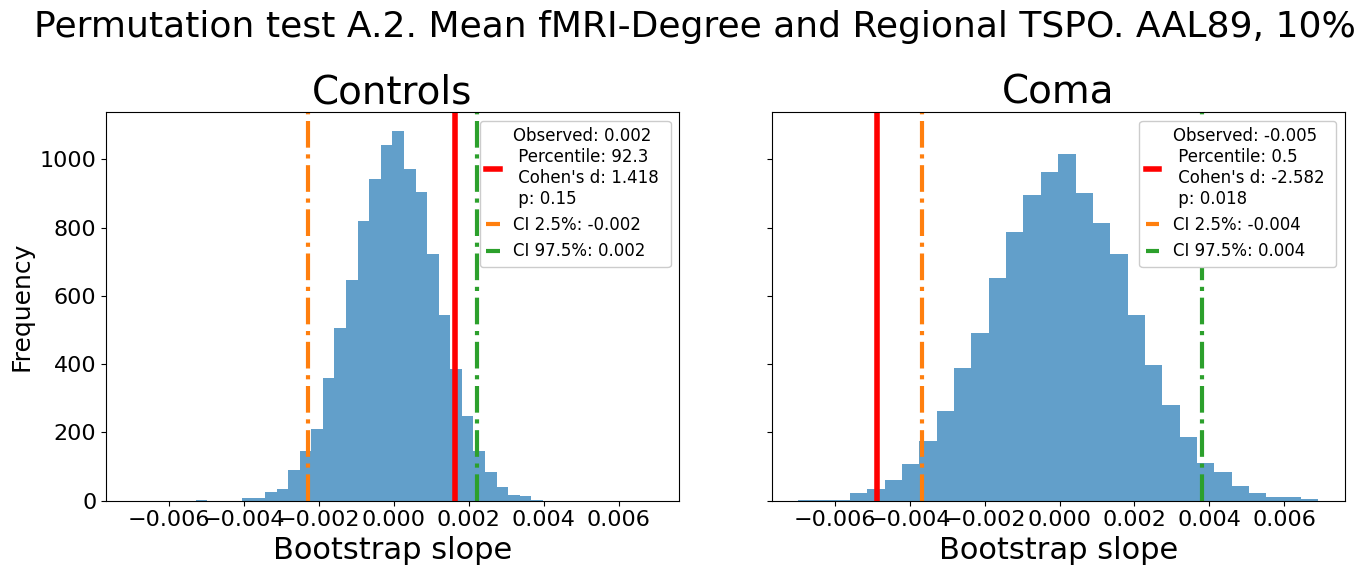

In [ ]:
metric = 'd'
groups = ['Controls', 'Coma']
xcost = 0.1  
p_print = [0.15, 0.018] # From previous cell
# make subplots (1 row, len(groups) columns)
fig, axes = plt.subplots(nrows=1, ncols=len(groups),
                         figsize=(14, 6), sharex=True, sharey=True)

# if there's only one row, axes is a 1D array
for j, group in enumerate(groups):
    ax = axes[j]
    
    # get the bootstrap slopes and the real slope
    boot_slopes = xcoeffs[group][xcost][metric]
    real_slope  = real_slopes[group][xcost][metric]
    
    # Percentile of the original slope in the bootstrapped distribution
    percentile = np.mean(boot_slopes < real_slope) * 100

    # Cohen's D
    cohens_d_value = cohens_d(real_slope, boot_slopes)

    # Confidence intervals
    ci_low = np.percentile(boot_slopes, 2.5)
    ci_high = np.percentile(boot_slopes, 97.5)

    # Plot histogram
    ax.hist(boot_slopes, bins=30, alpha=0.7, color="tab:blue")
    ax.axvline(real_slope, color='red', linestyle='-', linewidth=4,
               label=f"Observed: {real_slope:.3f} \n Percentile: {percentile:.1f} \n Cohen's d: {cohens_d_value:.3f} \n p: {p_print[j]}") 
    ax.axvline(ci_low, color='tab:orange', linestyle='-.', linewidth=3, label=f"CI 2.5%: {ci_low:.3f}")
    ax.axvline(ci_high, color='tab:green', linestyle='-.', linewidth=3, label=f"CI 97.5%: {ci_high:.3f}")

    # Titles and labels
    ax.set_title(group, fontsize=28)
    ax.set_xlabel('Bootstrap slope', fontsize=22)
    if j == 0:
        ax.set_ylabel("Frequency", fontsize=18)
    ax.tick_params(axis='both', labelsize=16)  # or any size you prefer
    legend = ax.legend(
        fontsize=12,
        handlelength=0.8,
        #handleheight=0.6,
        loc='best'
    )

    # Make the legend background fully opaque
    legend.get_frame().set_alpha(1.0)



# Overall figure title
fig.suptitle(f'Permutation test A.2. Mean fMRI-Degree and Regional TSPO. AAL89, 10%', fontsize=26)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
#plt.savefig("/H.2/H.2 AAL89 Bootstrap 10% 10k.png", dpi=300)

plt.show()


Storing results

In [20]:
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import fdrcorrection

metric = "d"
groups = ["Controls", "Coma"]
xcosts = sorted(xcoeffs["Controls"].keys())

rows = []

for cost in xcosts:

    p_values_uncorrected = []
    tmp = {}

    for group in groups:

        boot_slopes = np.asarray(xcoeffs[group][cost][metric])
        real_slope  = real_slopes[group][cost][metric]

        n = len(boot_slopes)

        # --- permutation p-value (two-tailed, +1 correction) ---
        extreme = np.sum(np.abs(boot_slopes) >= np.abs(real_slope))
        p_two_tailed = (extreme + 1) / (n + 1)

        p_values_uncorrected.append(p_two_tailed)

        # percentile (kept for reporting / plotting)
        percentile = np.mean(boot_slopes < real_slope)

        # effect size
        d_val = cohens_d(real_slope, boot_slopes)

        # confidence interval
        ci_low, ci_high = np.percentile(boot_slopes, [2.5, 97.5])

        tmp[group] = {
            "observed_slope": real_slope,
            "percentile": percentile,
            "p_raw": p_two_tailed,
            "cohens_d": d_val,
            "ci_low": ci_low,
            "ci_high": ci_high,
        }

    # ---- FDR correction across groups (within this cost) ----
    rejected, p_fdr = fdrcorrection(p_values_uncorrected, alpha=0.05)

    for group, fdr_p, reject in zip(groups, p_fdr, rejected):
        rows.append({
            "metric": metric,
            "cost": cost,
            "group": group,
            "observed_slope": tmp[group]["observed_slope"],
            "percentile": tmp[group]["percentile"],
            "cohens_d": tmp[group]["cohens_d"],
            "ci_low": tmp[group]["ci_low"],
            "ci_high": tmp[group]["ci_high"],
            "p_raw": tmp[group]["p_raw"],
            "p_fdr": fdr_p,
            "significant_fdr": reject
        })

df_stats_d = pd.DataFrame(rows)
df_stats_d


,metric,cost,group,observed_slope,percentile,cohens_d,ci_low,ci_high,p_raw,p_fdr,significant_fdr
0,d,0.05,Controls,0.002091,0.8084,0.870458,-0.004859,0.004629,0.391461,0.391461,False
1,d,0.05,Coma,-0.006614,0.0391,-1.753574,-0.007407,0.007766,0.080892,0.161784,False
2,d,0.10,Controls,0.001626,0.9227,1.418139,-0.002305,0.002207,0.161184,0.161184,False
3,d,0.10,Coma,-0.004871,0.0047,-2.581996,-0.003663,0.003815,0.010999,0.021998,True
4,d,0.15,Controls,0.001300,0.9487,1.624271,-0.001605,0.001533,0.106389,0.106389,False
5,d,0.15,Coma,-0.003705,0.0028,-2.739567,-0.002635,0.002698,0.006999,0.013999,True
6,d,0.20,Controls,0.001065,0.9539,1.662045,-0.001286,0.001236,0.096490,0.096490,False
7,d,0.20,Coma,-0.003264,0.0009,-2.956905,-0.002164,0.002189,0.002600,0.005199,True
8,d,0.25,Controls,0.000896,0.9500,1.626278,-0.001105,0.001064,0.103290,0.103290,False
9,d,0.25,Coma,-0.002873,0.0008,-2.980175,-0.001902,0.001930,0.002800,0.005599,True


In [ ]:
df_stats_d.to_csv("/home/cabrerar/Documents/Paper_1/Permutation_tests/Test_A/A.2/AAL_permutation_stats_degree_10k.csv", index=False)